In [1]:
import openml
from collections import Counter
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from greedy_algorithm.greedy import greedy_submodular_maximization, greedy_submodular_maximization_2

In [6]:
dataset = openml.datasets.get_dataset("Bioresponse") # Bioresponse dataset

In [7]:
X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format='dataframe'
)

In [8]:
len(attribute_names)

1776

In [9]:
y.value_counts()

target
1    2034
0    1717
Name: count, dtype: int64

In [10]:
Counter(categorical_indicator)

Counter({False: 1776})

# Training

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Initializing our budget (how many features we can train on)

In [10]:
k = 50

# Model 1 (all features)

In [9]:
print("\nTraining on ALL features...")
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_all.fit(X_train, y_train)
t_all = time.time() - t0

preds_all = rf_all.predict(X_test)
acc_all = accuracy_score(y_test, preds_all)
f1_all = f1_score(y_test, preds_all, average='macro')


Training on ALL features...


# Model 2 (random features)

In [10]:
print("\nTraining on RANDOM features...")
np.random.seed(42)
# Randomly select k unique column indices
random_indices = np.random.choice(X_train.shape[1], k, replace=False)

X_train_rand = X_train.iloc[:, random_indices]
X_test_rand = X_test.iloc[:, random_indices]

rf_rand = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_rand.fit(X_train_rand, y_train)
t_rand = time.time() - t0

preds_rand = rf_rand.predict(X_test_rand)
acc_rand = accuracy_score(y_test, preds_rand)
f1_rand = f1_score(y_test, preds_rand, average='macro')


Training on RANDOM features...


# Similarity matrix

In [11]:
print("\nCalculating correlation matrix (on X_train only)...")
corr_matrix = X_train.corr().abs().to_numpy().copy()
np.fill_diagonal(corr_matrix, 1.0) 


Calculating correlation matrix (on X_train only)...


In [12]:
np.isnan(corr_matrix).any()

np.True_

In [13]:
print("\nCalculating correlation matrix (on X_train only)...")
corr_matrix = X_train.corr().abs().fillna(0).to_numpy().copy()
np.fill_diagonal(corr_matrix, 1.0) 


Calculating correlation matrix (on X_train only)...


In [14]:
np.isnan(corr_matrix).any()

np.False_

# Model 3 (based on submodular approach)

In [15]:
print("Submodular selection...")
t0 = time.time()
submodular_indices = greedy_submodular_maximization(X_train.shape[1], k, corr_matrix)
t_select = time.time() - t0

Submodular selection...
Starting selection of 50 elements out of 1776...
Step 1: Selected element 504, Marginal Gain: 361.8194
Step 2: Selected element 1738, Marginal Gain: 123.5600
Step 3: Selected element 1336, Marginal Gain: 73.8409
Step 4: Selected element 850, Marginal Gain: 56.7635
Step 5: Selected element 2, Marginal Gain: 37.2594
Step 6: Selected element 448, Marginal Gain: 26.8270
Step 7: Selected element 1175, Marginal Gain: 25.6473
Step 8: Selected element 892, Marginal Gain: 22.6703
Step 9: Selected element 862, Marginal Gain: 21.9409
Step 10: Selected element 658, Marginal Gain: 17.6916
Step 11: Selected element 420, Marginal Gain: 13.3779
Step 12: Selected element 950, Marginal Gain: 10.5359
Step 13: Selected element 166, Marginal Gain: 9.4801
Step 14: Selected element 913, Marginal Gain: 7.8339
Step 15: Selected element 454, Marginal Gain: 7.8231
Step 16: Selected element 190, Marginal Gain: 7.7425
Step 17: Selected element 1604, Marginal Gain: 6.7498
Step 18: Selected e

In [19]:
X_train_sub = X_train.iloc[:, submodular_indices]
X_test_sub = X_test.iloc[:, submodular_indices]

print("Training on SUBMODULAR features...")
rf_sub = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_sub.fit(X_train_sub, y_train)
t_sub = time.time() - t0

preds_sub = rf_sub.predict(X_test_sub)
acc_sub = accuracy_score(y_test, preds_sub)
f1_sub = f1_score(y_test, preds_sub, average='macro')

Training on SUBMODULAR features...


# RESULTS

In [20]:
print("\n" + "="*50)
print("FINAL RESULTS:")
print("="*50)
print(f"1. ALL FEATURES ({X.shape[1]}):")
print(f"   Accuracy: {acc_all:.4f} | F1-Score: {f1_all:.4f} | Training time: {t_all:.2f}s")

print(f"\n2. RANDOM FEATURES ({k}):")
print(f"   Accuracy: {acc_rand:.4f} | F1-Score: {f1_rand:.4f} | Training time: {t_rand:.2f}s")

print(f"\n3. SUBMODULAR FEATURES ({k}):")
print(f"   Accuracy: {acc_sub:.4f} | F1-Score: {f1_sub:.4f} | Training time: {t_sub:.2f}s")
print(f"   (Feature selection time: {t_select:.2f}s)")


FINAL RESULTS:
1. ALL FEATURES (1776):
   Accuracy: 0.8003 | F1-Score: 0.7949 | Training time: 0.94s

2. RANDOM FEATURES (50):
   Accuracy: 0.7164 | F1-Score: 0.7079 | Training time: 0.24s

3. SUBMODULAR FEATURES (50):
   Accuracy: 0.7670 | F1-Score: 0.7628 | Training time: 0.23s
   (Feature selection time: 16.31s)


In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
preds_grid = best_rf.predict(X_test)

acc_grid = accuracy_score(y_test, preds_grid)
f1_grid = f1_score(y_test, preds_grid, average="macro")

print("Best hyperparameters:", grid_search.best_params_)
print(f"Grid search CV best score: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {acc_grid:.4f}")
print(f"Test F1-Score: {f1_grid:.4f}")

# GRID SEARCH

In [22]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

In [23]:
print("Running Grid Search on RANDOM features...")
grid_search_random = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid_search_random.fit(X_train_rand, y_train)

print("Running Grid Search on SUBMODULAR features...")
grid_search_sub = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid_search_sub.fit(X_train_sub, y_train)

Running Grid Search on RANDOM features...
Running Grid Search on SUBMODULAR features...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [24]:
# Convert cross-validation results to DataFrames
df_random_results = pd.DataFrame(grid_search_random.cv_results_)
df_sub_results = pd.DataFrame(grid_search_sub.cv_results_)

# Add a label column to identify which feature method was used
df_random_results["feature_method"] = "Random"
df_sub_results["feature_method"] = "Submodular"

In [25]:
df_all_results = pd.concat([df_random_results, df_sub_results], ignore_index=True)

In [26]:
columns_to_keep = [
    "feature_method",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "mean_test_score",  # This is the mean CV accuracy score
    "std_test_score",
    "mean_fit_time"
]
df_comparison = df_all_results[columns_to_keep].copy()

In [27]:
df_comparison.columns = [
    "Feature Method", "n_estimators", "max_depth", "min_samples_split", 
    "Mean CV Accuracy", "Std CV Accuracy", "Mean Fit Time (s)"
]

In [28]:
df_comparison

,Feature Method,n_estimators,max_depth,min_samples_split,Mean CV Accuracy,Std CV Accuracy,Mean Fit Time (s)
0,Random,50,None,2,0.700000,0.021551,1.132718
1,Random,100,None,2,0.703667,0.023224,2.845168
2,Random,200,None,2,0.704667,0.026737,7.448140
3,Random,50,None,5,0.703000,0.025871,0.811705
4,Random,100,None,5,0.707333,0.021746,1.669921
5,Random,200,None,5,0.711667,0.025232,3.918885
6,Random,50,None,10,0.706667,0.018318,0.669110
7,Random,100,None,10,0.709667,0.022886,2.326092
8,Random,200,None,10,0.709333,0.022351,9.622338
9,Random,50,10,2,0.683000,0.013638,1.383405


In [29]:
df_comparison_pivot = df_comparison.pivot_table(
    index=['n_estimators', 'max_depth', 'min_samples_split'],
    columns='Feature Method',
    values=['Mean CV Accuracy', 'Std CV Accuracy', 'Mean Fit Time (s)']
)

df_comparison_pivot.columns = [f"{metric} ({method})" for metric, method in df_comparison_pivot.columns]
df_comparison_pivot = df_comparison_pivot.reset_index()

In [30]:
df_comparison_pivot

,n_estimators,max_depth,min_samples_split,Mean CV Accuracy (Random),Mean CV Accuracy (Submodular),Mean Fit Time (s) (Random),Mean Fit Time (s) (Submodular),Std CV Accuracy (Random),Std CV Accuracy (Submodular)
0,50,10,2,0.683000,0.729333,1.383405,0.174424,0.013638,0.018991
1,50,10,5,0.675667,0.734667,1.291158,0.174414,0.012936,0.011324
2,50,10,10,0.685333,0.730000,2.355235,0.409076,0.017839,0.015055
3,50,20,2,0.704667,0.759667,1.160353,0.287687,0.022071,0.027088
4,50,20,5,0.705000,0.750333,0.630214,0.236231,0.021396,0.017429
5,50,20,10,0.704667,0.749667,0.705051,0.216573,0.023224,0.017365
6,100,10,2,0.685000,0.737333,6.282473,0.357882,0.012202,0.017594
7,100,10,5,0.682333,0.732000,3.537838,0.546824,0.016620,0.015825
8,100,10,10,0.685667,0.732667,2.573114,0.456619,0.014704,0.013482
9,100,20,2,0.710667,0.758000,1.757095,0.509572,0.025113,0.021484


In [32]:
# Evaluate best Random model
best_rf_random = grid_search_random.best_estimator_
acc_test_random = accuracy_score(y_test, best_rf_random.predict(X_test_rand))

In [33]:
# Evaluate best Submodular model
best_rf_sub = grid_search_sub.best_estimator_
acc_test_sub = accuracy_score(y_test, best_rf_sub.predict(X_test_sub))

In [34]:
print("\nTest Accuracy of best Random model:", acc_test_random)
print("Test Accuracy of best Submodular model:", acc_test_sub)


Test Accuracy of best Random model: 0.7283621837549934
Test Accuracy of best Submodular model: 0.7643142476697736


In [ ]:
num_trials = k  # use existing k
train_accs = []
test_accs = []

for i in range(num_trials):
    rng = np.random.RandomState(42 + i)
    cols = rng.choice(X_train.shape[1], k, replace=False)
    Xtr = X_train.iloc[:, cols]
    Xte = X_test.iloc[:, cols]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(Xtr, y_train)

    train_accs.append(accuracy_score(y_train, clf.predict(Xtr)))
    test_accs.append(accuracy_score(y_test, clf.predict(Xte)))

train_accuracy_mean = np.mean(train_accs)
test_accuracy_mean = np.mean(test_accs)

print(f"Mean training accuracy over {num_trials} runs: {train_accuracy_mean:.4f}")
print(f"Mean test accuracy over {num_trials} runs:     {test_accuracy_mean:.4f}")

### Other tests

In [15]:
# Import the new advanced functions from your updated greedy.py
from greedy_algorithm.greedy import greedy_submodular_maximization_2, facility_location_score

# Ensure data is in numpy format for indexing speed
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)

# 1. Compute similarity matrix
print("Computing absolute Pearson correlation matrix for Bioresponse features...")
bio_sim_matrix = np.abs(np.corrcoef(X_train_np.T))
np.nan_to_num(bio_sim_matrix, copy=False, nan=0.0)

V_SIZE_BIO = bio_sim_matrix.shape[0]
BUDGET_K = 50

# 2. Execute Submodular Selections using our updated toolbox
selected_fac_loc = greedy_submodular_maximization_2(V_SIZE_BIO, BUDGET_K, 'facility_location', bio_sim_matrix)
selected_log_det = greedy_submodular_maximization_2(V_SIZE_BIO, BUDGET_K, 'log_determinant', bio_sim_matrix)

# 3. Mathematical Data-Dependent Online Upper Bound Function (Kept in notebook as it's an evaluation step)
def compute_online_upper_bound(S, sim_matrix, k):
    curr_score = facility_location_score(S, sim_matrix)
    all_gains = []
    for v in range(sim_matrix.shape[0]):
        if v in S: 
            continue
        all_gains.append(facility_location_score(S + [v], sim_matrix) - curr_score)
    top_k_gains = sorted(all_gains, reverse=True)[:k]
    return curr_score + sum(top_k_gains)

ub_fac_loc = compute_online_upper_bound(selected_fac_loc, bio_sim_matrix, BUDGET_K)
nemhauser_ub = facility_location_score(selected_fac_loc, bio_sim_matrix) / (1 - (1 / np.e))

print("\n" + "="*60)
print("SUBMODULAR THEORETICAL BOUNDS FOR BIORESPONSE (Facility Location):")
print(f"Greedy Solution Score:          {facility_location_score(selected_fac_loc, bio_sim_matrix):.4f}")
print(f"Data-Dependent Online Upper Bound: {ub_fac_loc:.4f} (Tightest possible bound)")
print(f"Nemhauser Offline Upper Bound:     {nemhauser_ub:.4f}")

Computing absolute Pearson correlation matrix for Bioresponse features...
Starting greedy selection using facility_location (k=50)...
  Step 1/50: Selected feature 504, Marginal Gain: 361.8194


c:\Users\Anna Kozłowska\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Anna Kozłowska\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Step 10/50: Selected feature 658, Marginal Gain: 17.6916
  Step 20/50: Selected feature 277, Marginal Gain: 6.2379
  Step 30/50: Selected feature 216, Marginal Gain: 4.2274
  Step 40/50: Selected feature 605, Marginal Gain: 3.1115
  Step 50/50: Selected feature 451, Marginal Gain: 2.4709
Starting greedy selection using log_determinant (k=50)...
  Step 1/50: Selected feature 0, Marginal Gain: 0.0001
  Step 10/50: Selected feature 245, Marginal Gain: -0.0003
  Step 20/50: Selected feature 238, Marginal Gain: -0.0017
  Step 30/50: Selected feature 307, Marginal Gain: -0.0053
  Step 40/50: Selected feature 510, Marginal Gain: -0.0152
  Step 50/50: Selected feature 825, Marginal Gain: -0.0263


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

Computing absolute Pearson correlation matrix for Bioresponse features...
Starting greedy selection using facility_location (k=50)...
  Step 1/50: Selected feature 504, Marginal Gain: 361.8194
  Step 10/50: Selected feature 658, Marginal Gain: 17.6916
  Step 20/50: Selected feature 277, Marginal Gain: 6.2379
  Step 30/50: Selected feature 216, Marginal Gain: 4.2274
  Step 40/50: Selected feature 605, Marginal Gain: 3.1115
  Step 50/50: Selected feature 451, Marginal Gain: 2.4709
Starting greedy selection using saturated_coverage (k=50)...
  Step 1/50: Selected feature 504, Marginal Gain: 361.8194
  Step 10/50: Selected feature 4, Marginal Gain: 30.5379
  Step 20/50: Selected feature 107, Marginal Gain: 3.8996
  Step 30/50: Selected feature 233, Marginal Gain: 0.5890
  Step 40/50: Selected feature 9, Marginal Gain: 0.0000
  Step 50/50: Selected feature 22, Marginal Gain: 0.0000


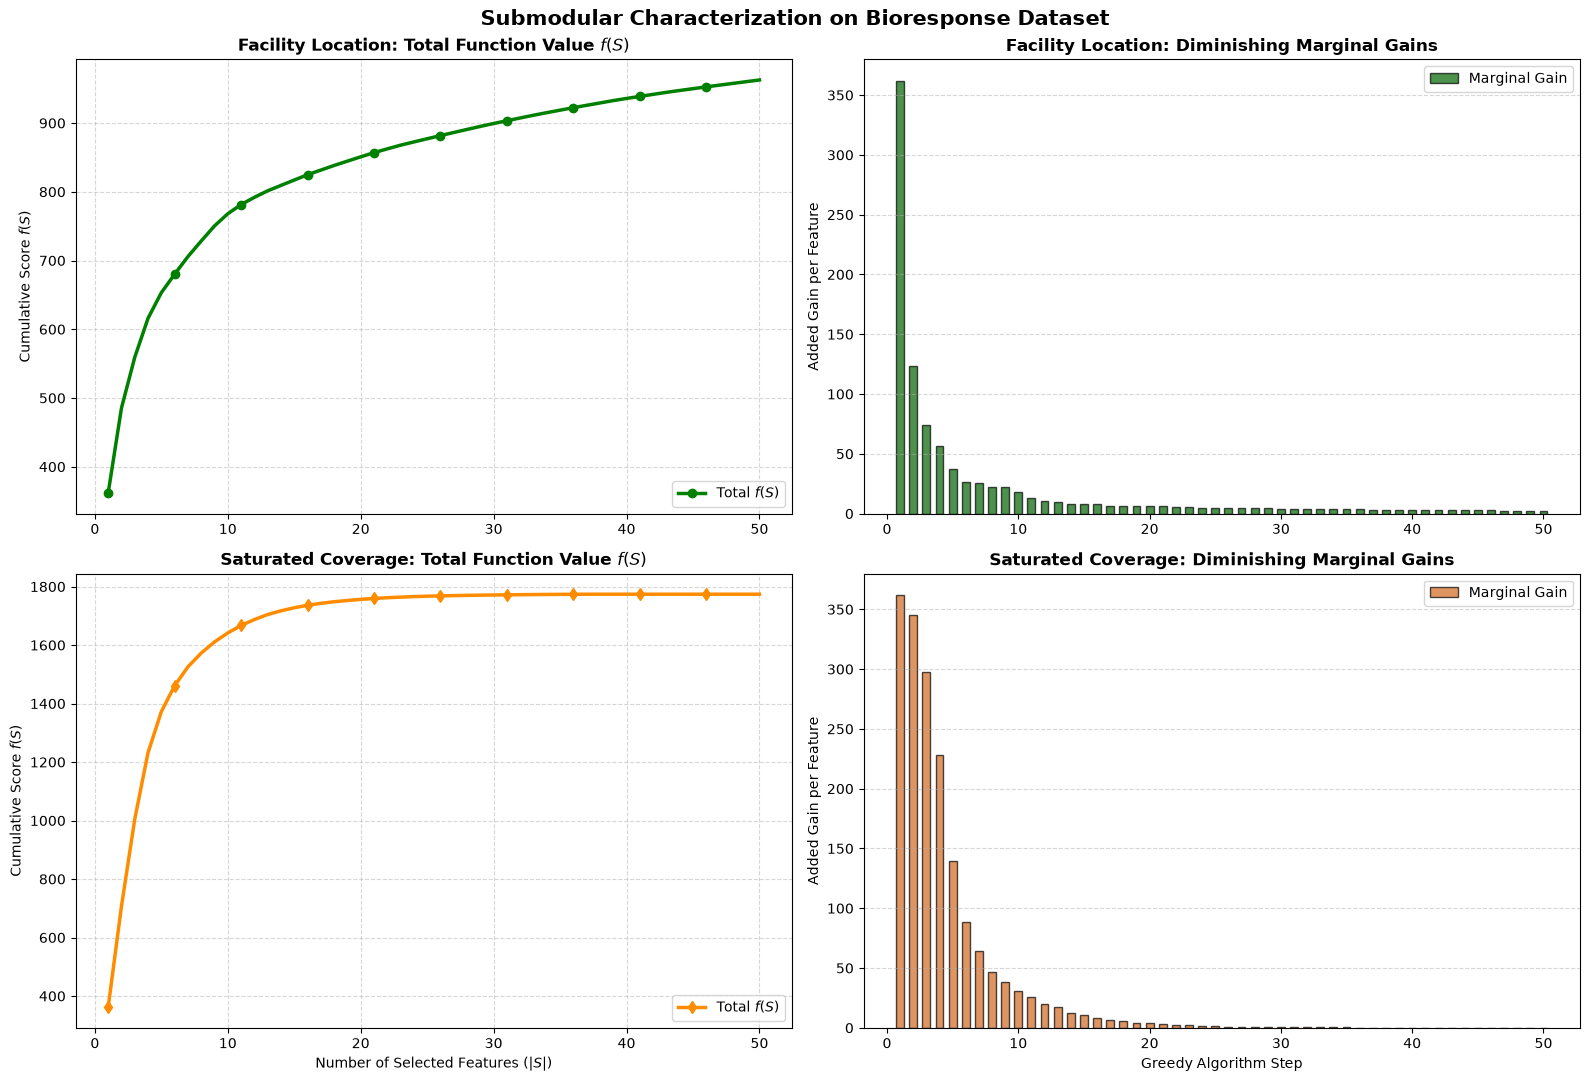

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from greedy_algorithm.greedy import greedy_submodular_maximization_2, facility_location_score, saturated_coverage_score

# --- 1. RECONSTRUCT TOTAL UTILITY HISTORY FROM THE EXPERIMENT ---
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)

# 1. Compute similarity matrix
print("Computing absolute Pearson correlation matrix for Bioresponse features...")
bio_sim_matrix = np.abs(np.corrcoef(X_train_np.T))
np.nan_to_num(bio_sim_matrix, copy=False, nan=0.0)

V_SIZE_BIO = bio_sim_matrix.shape[0]
budget_k = 50  # Ujednolicamy wielkość liter
steps = np.arange(1, budget_k + 1)

# Uruchamiamy algorytm dla OBU funkcji celu, które chcesz narysować na wykresie
selected_fac_loc, gains_fac_loc = greedy_submodular_maximization_2(V_SIZE_BIO, budget_k, 'facility_location', bio_sim_matrix)
selected_sat_cov, gains_sat_cov = greedy_submodular_maximization_2(V_SIZE_BIO, budget_k, 'saturated_coverage', bio_sim_matrix, alpha=1.0)

# Obliczanie granic matematycznych dla Facility Location
ub_fac_loc = compute_online_upper_bound(selected_fac_loc, bio_sim_matrix, budget_k)
nemhauser_ub = facility_location_score(selected_fac_loc, bio_sim_matrix) / (1 - (1 / np.e))

total_utility_fl = []
total_utility_sc = []

# Pętla rekonstruująca historię wzrostu funkcji celu krok po kroku
for step in range(1, budget_k + 1):
    # Slice the first 'step' features
    sub_fl = selected_fac_loc[:step]
    sub_sc = selected_sat_cov[:step]
    
    # Obliczamy skumulowane punkty używając właściwej macierzy: bio_sim_matrix
    total_utility_fl.append(facility_location_score(sub_fl, bio_sim_matrix))
    total_utility_sc.append(saturated_coverage_score(sub_sc, bio_sim_matrix, alpha=1.0))

# --- 2. PLOT THE CUMULATIVE VALUE VS MARGINAL GAINS (REAL DATA) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Submodular Characterization on Bioresponse Dataset", fontsize=15, fontweight='bold', y=0.98)

# --- PANEL A: FACILITY LOCATION ANALYSIS ---
# Cumulative Growth f(S)
axes[0, 0].plot(steps, total_utility_fl, color='green', linewidth=2.5, marker='o', markevery=5, label='Total $f(S)$')
axes[0, 0].set_title("Facility Location: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Cumulative Score $f(S)$")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(loc='lower right')

# Marginal Gains (History from greedy algorithm output)
axes[0, 1].bar(steps, gains_fac_loc, color='darkgreen', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes[0, 1].set_title("Facility Location: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Added Gain per Feature")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes[0, 1].legend(loc='upper right')

# --- PANEL B: SATURATED COVERAGE ANALYSIS ---
# Cumulative Growth f(S)
axes[1, 0].plot(steps, total_utility_sc, color='darkorange', linewidth=2.5, marker='d', markevery=5, label='Total $f(S)$')
axes[1, 0].set_title("Saturated Coverage: Total Function Value $f(S)$", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Number of Selected Features ($|S|$)")
axes[1, 0].set_ylabel("Cumulative Score $f(S)$")
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(loc='lower right')

# Marginal Gains (History from greedy algorithm output)
axes[1, 1].bar(steps, gains_sat_cov, color='chocolate', alpha=0.7, edgecolor='black', width=0.6, label='Marginal Gain')
axes[1, 1].set_title("Saturated Coverage: Diminishing Marginal Gains", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Greedy Algorithm Step")
axes[1, 1].set_ylabel("Added Gain per Feature")
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

Starting greedy selection using facility_location (k=50)...
  Step 1/50: Selected feature 504, Marginal Gain: 361.8194
  Step 10/50: Selected feature 658, Marginal Gain: 17.6916
  Step 20/50: Selected feature 277, Marginal Gain: 6.2379
  Step 30/50: Selected feature 216, Marginal Gain: 4.2274
  Step 40/50: Selected feature 605, Marginal Gain: 3.1115
  Step 50/50: Selected feature 451, Marginal Gain: 2.4709
Starting greedy selection using log_determinant (k=50)...
  Step 1/50: Selected feature 0, Marginal Gain: 0.0001
  Step 10/50: Selected feature 245, Marginal Gain: -0.0003
  Step 20/50: Selected feature 238, Marginal Gain: -0.0017
  Step 30/50: Selected feature 307, Marginal Gain: -0.0053
  Step 40/50: Selected feature 510, Marginal Gain: -0.0152
  Step 50/50: Selected feature 825, Marginal Gain: -0.0263
Starting greedy selection using saturated_coverage (k=50)...
  Step 1/50: Selected feature 504, Marginal Gain: 361.8194
  Step 10/50: Selected feature 4, Marginal Gain: 30.5379
  Ste

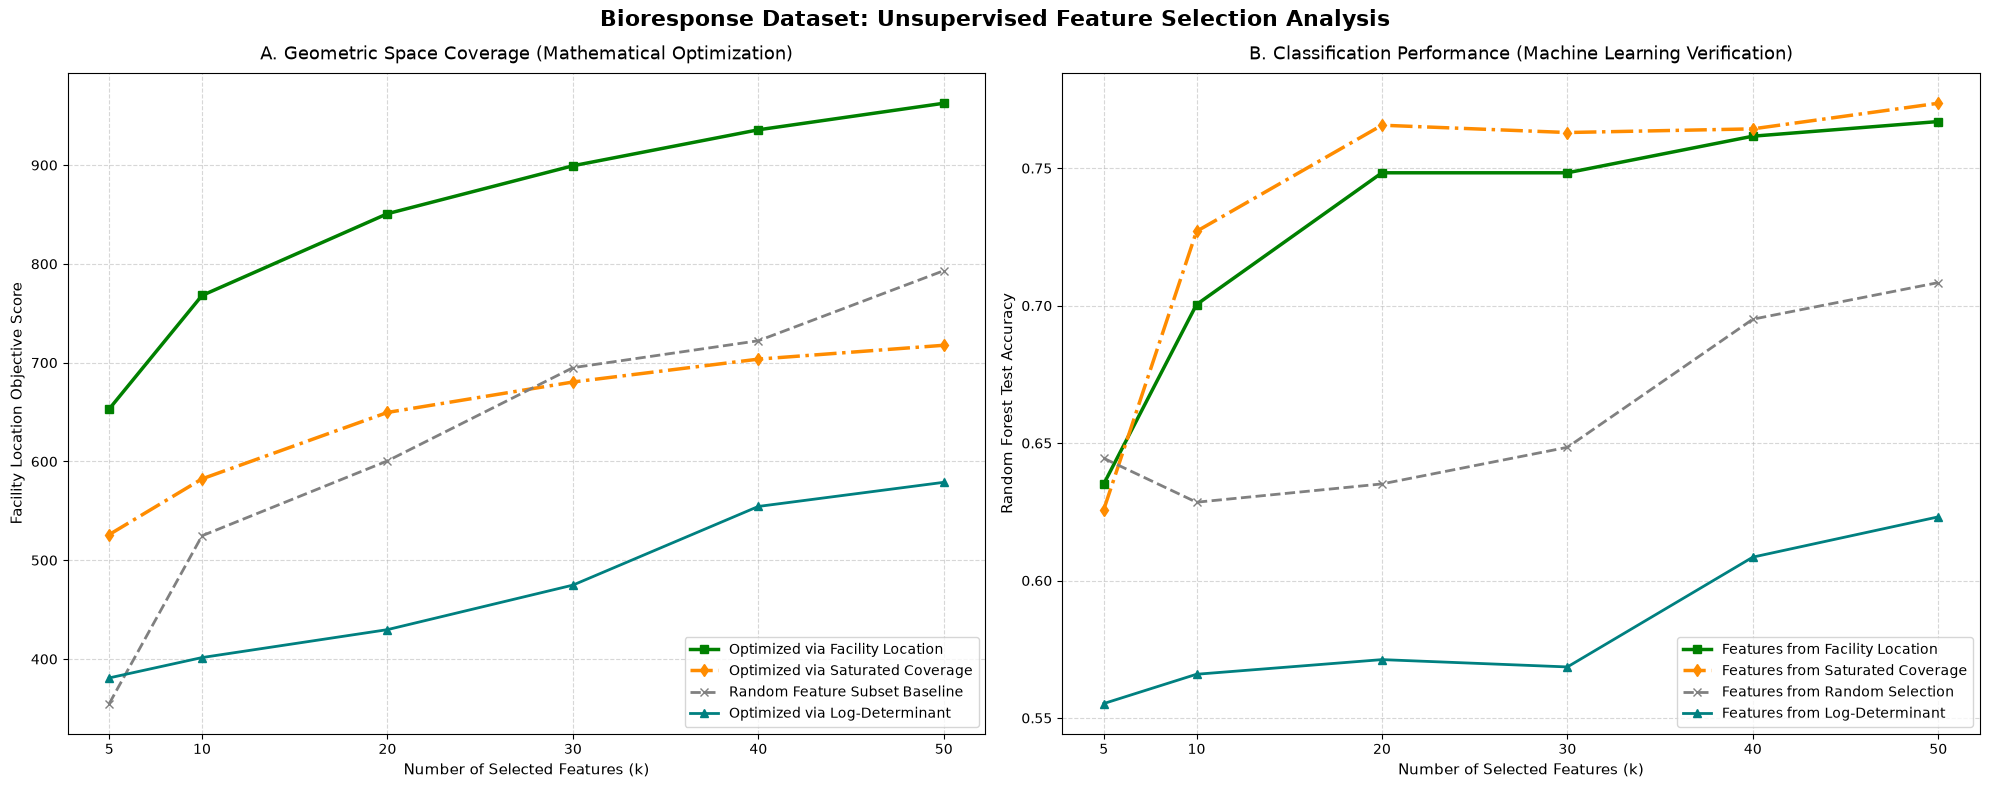

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- STEP 1: AUTOMATIC SIMILARITY MATRIX GENERATION ---
# Using absolute Pearson correlation matrix as similarity measure
correlation_matrix = X_train.corr().abs().fillna(0.0)
sim_matrix = correlation_matrix.to_numpy()

# --- CONFIGURATION VARIABLES ---
budget_k = 50
ground_set_size = X_train.shape[1]
k_milestones = [5, 10, 20, 30, 40, 50]

# Convert datasets to numpy arrays safely to support direct [:, index] slicing
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)
y_train_np = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else np.array(y_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else np.array(X_test)
y_test_np = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.array(y_test)

# --- STEP 2: RUN GREEDY MAXIMIZATION FOR THE MAX BUDGET (k=50) ---
selected_fac_loc, gains_fac_loc = greedy_submodular_maximization_2(ground_set_size, budget_k, 'facility_location', sim_matrix)
selected_log_det, gains_log_det = greedy_submodular_maximization_2(ground_set_size, budget_k, 'log_determinant', sim_matrix)
selected_sat_cov, gains_sat_cov = greedy_submodular_maximization_2(ground_set_size, budget_k, 'saturated_coverage', sim_matrix, alpha=1.0)

# --- STEP 3: MILESTONE PERFORMANCE LOOPS (YOUR EXACT METHOD) ---
scores_acc_fac_loc = []
scores_acc_log_det = []
scores_acc_sat_cov = []
scores_acc_random = []

# Optional: To reproduce Chart A, we will trace the theoretical Facility Location Score 
# achieved by each method at different milestone sizes
scores_math_fac_loc = []
scores_math_log_det = []
scores_math_sat_cov = []
scores_math_random = []

for k_val in k_milestones:
    # 1. Evaluate Facility Location Subsets
    idx_fl = selected_fac_loc[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_fl], y_train_np)
    scores_acc_fac_loc.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_fl])))
    scores_math_fac_loc.append(facility_location_score(idx_fl, sim_matrix))
    
    # 2. Evaluate Log-Determinant Subsets
    idx_ld = selected_log_det[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_ld], y_train_np)
    scores_acc_log_det.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_ld])))
    scores_math_log_det.append(facility_location_score(idx_ld, sim_matrix))
    
    # 3. Evaluate Saturated Coverage Subsets
    idx_sc = selected_sat_cov[:k_val]
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_sc], y_train_np)
    scores_acc_sat_cov.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_sc])))
    scores_math_sat_cov.append(facility_location_score(idx_sc, sim_matrix))
    
    # 4. Evaluate Random Subset Baseline
    np.random.seed(42 + k_val)
    idx_rand = np.random.choice(ground_set_size, k_val, replace=False).tolist()
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_np[:, idx_rand], y_train_np)
    scores_acc_random.append(accuracy_score(y_test_np, clf.predict(X_test_np[:, idx_rand])))
    scores_math_random.append(facility_location_score(idx_rand, sim_matrix))

# --- STEP 4: PLOT ORIGINAL ANALYSIS PLOTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Bioresponse Dataset: Unsupervised Feature Selection Analysis", fontsize=16, fontweight='bold', y=0.98)

# Chart A: Geometric Space Coverage (Mathematical Score Profile)
ax1.plot(k_milestones, scores_math_fac_loc, marker='s', label='Optimized via Facility Location', linewidth=2.5, color='green')
ax1.plot(k_milestones, scores_math_sat_cov, marker='d', label='Optimized via Saturated Coverage', linewidth=2.5, linestyle='-.', color='darkorange')
ax1.plot(k_milestones, scores_math_random, marker='x', label='Random Feature Subset Baseline', linestyle='--', linewidth=2.0, color='gray')
ax1.plot(k_milestones, scores_math_log_det, marker='^', label='Optimized via Log-Determinant', linewidth=2.0, color='teal')

ax1.set_title("A. Geometric Space Coverage (Mathematical Optimization)", fontsize=13, pad=10)
ax1.set_xlabel("Number of Selected Features (k)", fontsize=11)
ax1.set_ylabel("Facility Location Objective Score", fontsize=11)
ax1.set_xticks(k_milestones)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=10)

# Chart B: Classification Accuracy Profile
ax2.plot(k_milestones, scores_acc_fac_loc, marker='s', label='Features from Facility Location', linewidth=2.5, color='green')
ax2.plot(k_milestones, scores_acc_sat_cov, marker='d', label='Features from Saturated Coverage', linewidth=2.5, linestyle='-.', color='darkorange')
ax2.plot(k_milestones, scores_acc_random, marker='x', label='Features from Random Selection', linestyle='--', linewidth=2.0, color='gray')
ax2.plot(k_milestones, scores_acc_log_det, marker='^', label='Features from Log-Determinant', linewidth=2.0, color='teal')

ax2.set_title("B. Classification Performance (Machine Learning Verification)", fontsize=13, pad=10)
ax2.set_xlabel("Number of Selected Features (k)", fontsize=11)
ax2.set_ylabel("Random Forest Test Accuracy", fontsize=11)
ax2.set_xticks(k_milestones)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()